# Fase 2 — Validación Loader
Verifica imputación, split temporal y mappings.

In [1]:
import sys
sys.path.insert(0, '/app')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data.loader import (
    load_raw, impute, temporal_split,
    build_mappings, get_valid_combinations,
    COL_FECHA, COL_LOCAL, COL_PRODUCTO,
    COL_UNIDADES, COL_MONTO, COL_STOCK
)

print('Imports OK')

Imports OK


## 1. DataFrame antes de imputación

In [2]:
print('Cargando...')
df_raw = load_raw()
print(f'Shape: {df_raw.shape}')
print()
print('NaN por columna ANTES de imputación:')
print(df_raw.isnull().sum())
print()
print('Negativos por columna ANTES:')
for col in [COL_UNIDADES, COL_MONTO, COL_STOCK]:
    n_neg = (df_raw[col] < 0).sum()
    print(f'  {col}: {n_neg:,} negativos')
print()

Cargando...
Shape: (6062390, 6)

NaN por columna ANTES de imputación:
date                0
store_id        47057
retailer_sku        0
units               0
revenue             0
stock               0
dtype: int64

Negativos por columna ANTES:
  units: 683 negativos
  revenue: 856 negativos
  stock: 64,730 negativos



## 2. DataFrame después de imputación

In [3]:
print('Imputando...')
df = impute(df_raw)
print(f'Shape: {df.shape}')
print()
print('NaN por columna DESPUÉS de imputación:')
print(df.isnull().sum())
print()
print('Negativos por columna DESPUÉS:')
for col in [COL_UNIDADES, COL_MONTO, COL_STOCK, 'precio']:
    n_neg = (df[col] < 0).sum()
    print(f'  {col}: {n_neg:,} negativos')
print()

Imputando...
Shape: (6015333, 7)

NaN por columna DESPUÉS de imputación:
date            0
store_id        0
retailer_sku    0
units           0
revenue         0
stock           0
precio          0
dtype: int64

Negativos por columna DESPUÉS:
  units: 0 negativos
  revenue: 0 negativos
  stock: 0 negativos
  precio: 0 negativos



## 3. Distribuciones

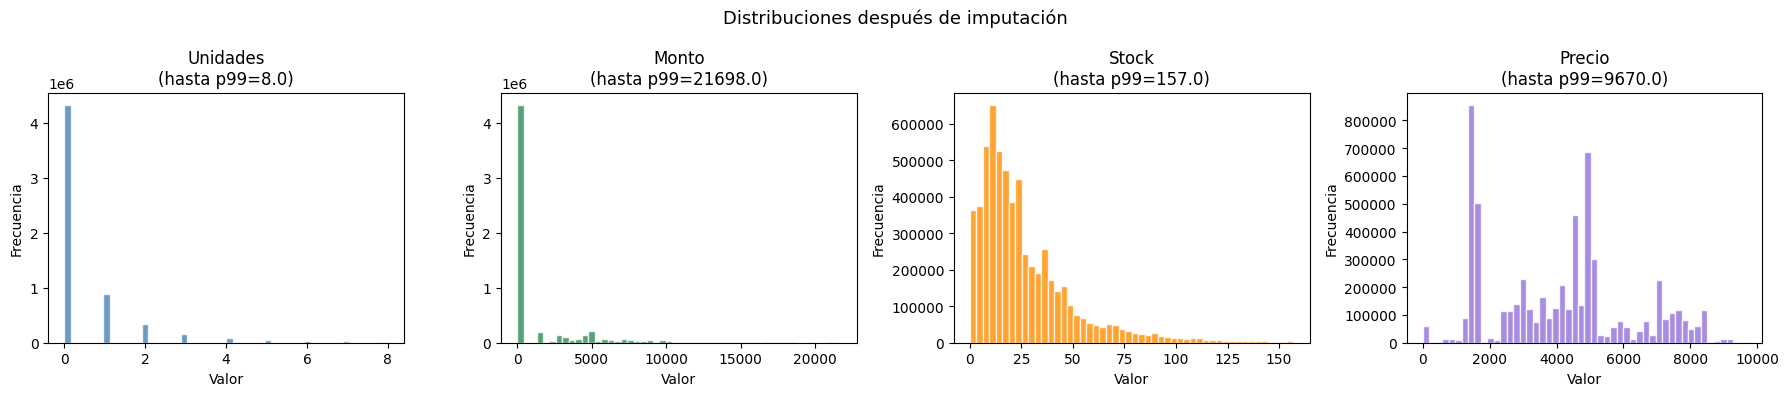

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

cols = [COL_UNIDADES, COL_MONTO, COL_STOCK, 'precio']
colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']
titles = ['Unidades', 'Monto', 'Stock', 'Precio']

for ax, col, color, title in zip(axes, cols, colors, titles):
    # Recortamos outliers extremos para visualización
    data = df[col].dropna()
    p99  = data.quantile(0.99)
    data_plot = data[data <= p99]
    ax.hist(data_plot, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{title}\n(hasta p99={p99:.1f})')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribuciones después de imputación', fontsize=13)
plt.tight_layout()
plt.savefig('/app/outputs/visualizations/fase2_distribuciones.png', dpi=100)
plt.show()

## 4. Split temporal

In [5]:
train, val, test = temporal_split(df)

print('=== SPLIT TEMPORAL ===')
print(f'Train: {len(train):>10,} filas | {train[COL_FECHA].min().date()} → {train[COL_FECHA].max().date()}')
print(f'Val:   {len(val):>10,} filas | {val[COL_FECHA].min().date()} → {val[COL_FECHA].max().date()}')
print(f'Test:  {len(test):>10,} filas | {test[COL_FECHA].min().date()} → {test[COL_FECHA].max().date()}')
print()

# Verificación crítica: no hay leak temporal
assert train[COL_FECHA].max() < val[COL_FECHA].min(), 'ERROR: leak train→val'
assert val[COL_FECHA].max() < test[COL_FECHA].min(), 'ERROR: leak val→test'
print('✅ max(train.fecha) < min(val.fecha) < min(test.fecha) — sin leak temporal')

=== SPLIT TEMPORAL ===
Train:  4,138,281 filas | 2024-03-11 → 2025-08-07
Val:      930,250 filas | 2025-08-08 → 2025-11-25
Test:     946,802 filas | 2025-11-26 → 2026-03-15

✅ max(train.fecha) < min(val.fecha) < min(test.fecha) — sin leak temporal


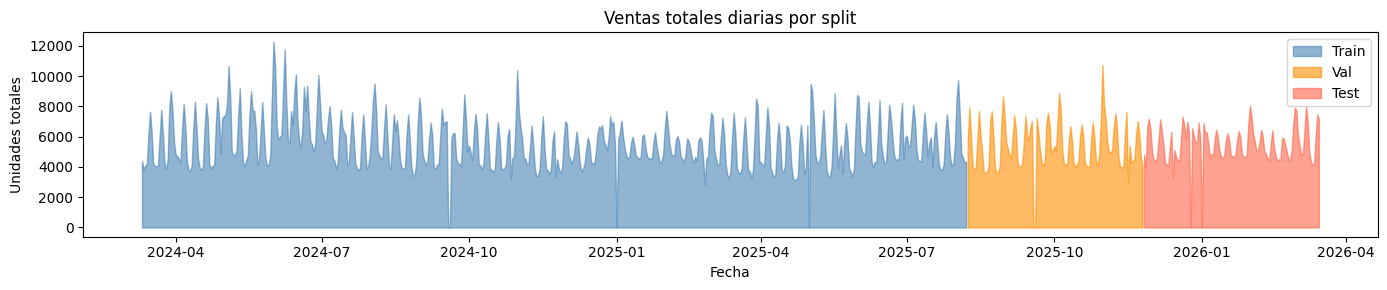

In [6]:
# Visualización del split en el tiempo
fig, ax = plt.subplots(figsize=(14, 3))

for split, color, label in [
    (train, 'steelblue', 'Train'),
    (val,   'darkorange', 'Val'),
    (test,  'tomato', 'Test')
]:
    daily = split.groupby(COL_FECHA)[COL_UNIDADES].sum()
    ax.fill_between(daily.index, daily.values, alpha=0.6, color=color, label=label)

ax.set_title('Ventas totales diarias por split')
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades totales')
ax.legend()
plt.tight_layout()
plt.savefig('/app/outputs/visualizations/fase2_split.png', dpi=100)
plt.show()

## 5. Mappings y combinaciones válidas

In [7]:
local_map, product_map = build_mappings(df)
valid_combos = get_valid_combinations(df)

print(f'Locales únicos:    {len(local_map):,}')
print(f'Productos únicos:  {len(product_map):,}')
print(f'Combinaciones válidas (>=120 días): {len(valid_combos):,}')
print()
print('Distribución de días por combinación válida:')
print(valid_combos['n_dias'].describe().round(1))

Locales únicos:    1,029
Productos únicos:  179
Combinaciones válidas (>=120 días): 12,358

Distribución de días por combinación válida:
count    12358.0
mean       475.2
std        229.9
min        104.0
25%        245.0
50%        540.0
75%        720.0
max        732.0
Name: n_dias, dtype: float64


## 6. Resumen final

In [8]:
print('=== RESUMEN FASE 2 ===')
print(f'Filas totales:              {len(df):,}')
print(f'NaN restantes:              {df.isnull().sum().sum()}')
print(f'Negativos restantes:        {(df[[COL_UNIDADES, COL_MONTO, COL_STOCK]] < 0).sum().sum()}')
print(f'Split sin leak temporal:    ✅')
print(f'Locales mapeados:           {len(local_map):,}')
print(f'Productos mapeados:         {len(product_map):,}')
print(f'Combinaciones entrenables:  {len(valid_combos):,}')

estado_nan = '✅' if df.isnull().sum().sum() == 0 else '⚠️'
estado_neg = '✅' if (df[[COL_UNIDADES, COL_MONTO, COL_STOCK]] < 0).sum().sum() == 0 else '⚠️'
print(f'Estado NaN:                 {estado_nan}')
print(f'Estado negativos:           {estado_neg}')

=== RESUMEN FASE 2 ===
Filas totales:              6,015,333
NaN restantes:              0
Negativos restantes:        0
Split sin leak temporal:    ✅
Locales mapeados:           1,029
Productos mapeados:         179
Combinaciones entrenables:  12,358
Estado NaN:                 ✅
Estado negativos:           ✅
